# 04. Error Types and Propagation

**Part 1: Foundations of Numerical Computing**

## Learning objectives

By the end of this lesson you will be able to:

1. Define **absolute**, **relative** and **percentage** error, and say which one to use when.
2. Name every source of error in a computation: **modeling**, **inherent**, **blunder**,
   **round-off** and **truncation**.
3. Derive how error **propagates** through the four arithmetic operations.
4. Derive the propagation rule for a function of **one** variable and of **several**
   variables.
5. Estimate the number of **correct significant digits** in a computed result.
6. Predict how error **accumulates** over many operations, and check the prediction.

## Prerequisites

Lesson 03, particularly the standard model $\mathrm{fl}(a \circ b) = (a \circ b)(1+\delta)$
with $|\delta| \le u$. This lesson is about what happens when you apply that model thousands
of times in a row.

---

## 1. The three basic measures

Let $x$ be the true value and $\hat{x}$ the computed one.

> **Definition 4.1.**
>
> $$\text{absolute error} = |x - \hat{x}|, \qquad
> \text{relative error} = \frac{|x - \hat{x}|}{|x|}, \qquad
> \text{percentage error} = 100 \cdot \frac{|x - \hat{x}|}{|x|}.$$
>
> Relative error is undefined when $x = 0$.

**Which one should you use?** Almost always the relative one. An absolute error of $0.001$ is
excellent if the answer is $10^6$ and catastrophic if the answer is $10^{-6}$. Absolute error
means nothing without knowing the scale.

There are two exceptions where absolute error is the right measure: when the true value can
legitimately be zero, and when the quantity has a natural additive scale, such as an angle or
a temperature difference.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import errors as err

cases = [
    ("large value",  1_000_000.0, 1_000_000.001),
    ("small value",  0.000001,    0.000002),
    ("near zero",    0.0,         1e-12),
]

print(f"{'case':>14} {'exact':>14} {'approx':>14} {'absolute':>12} {'relative':>12}")
print("-" * 70)
for name, exact, approx in cases:
    print(f"{name:>14} {exact:>14.6g} {approx:>14.6g} "
          f"{err.absolute_error(exact, approx):>12.3e} "
          f"{err.relative_error(exact, approx):>12.3e}")

print("\nrow 1 and row 2 have almost the same absolute error.")
print("row 2 is wrong by 100 percent, row 1 by a billionth of a percent.")
print("row 3 shows why relative error is undefined at zero: it reports infinity.")

          case          exact         approx     absolute     relative
----------------------------------------------------------------------
   large value          1e+06          1e+06    1.000e-03    1.000e-09
   small value          1e-06          2e-06    1.000e-06    1.000e+00
     near zero              0          1e-12    1.000e-12          inf

row 1 and row 2 have almost the same absolute error.
row 2 is wrong by 100 percent, row 1 by a billionth of a percent.
row 3 shows why relative error is undefined at zero: it reports infinity.


## 2. Correct significant digits

A more human measure. If the relative error is about $10^{-p}$, you have about $p$ correct
significant decimal digits.

> **Definition 4.2.** The number of correct significant digits in $\hat{x}$ is
> $-\log_{10}(\text{relative error})$.

This is the practical meaning of the unit roundoff. With $u \approx 1.1 \times 10^{-16}$, a
single correctly rounded double carries about $16$ correct digits. Every digit you lose after
that is a digit your algorithm threw away.

In [3]:
print(f"{'relative error':>16} {'correct digits':>16}")
print("-" * 34)
for rel in [1e-1, 1e-3, 1e-8, 1e-12, 1e-16]:
    approx = 1.0 * (1 + rel)
    print(f"{rel:>16.0e} {err.significant_digits(1.0, approx):>16.1f}")

print(f"\nunit roundoff u = {np.finfo(float).eps/2:.3e}")
print(f"so a perfectly rounded double carries about "
      f"{-np.log10(np.finfo(float).eps/2):.1f} correct digits. that is the ceiling.")

  relative error   correct digits
----------------------------------
           1e-01              1.0
           1e-03              3.0
           1e-08              8.0
           1e-12             12.0
           1e-16             16.0

unit roundoff u = 1.110e-16
so a perfectly rounded double carries about 16.0 correct digits. that is the ceiling.


## 3. Where errors come from

Not every error is roundoff. Sorting them out matters, because they have different cures.

| Source | What it is | Can numerical analysis fix it? |
|---|---|---|
| **Modeling error** | The equations do not describe reality perfectly. Ignoring air resistance, assuming a rod is perfectly rigid. | No. This is a modelling decision, made before any computation. |
| **Inherent error** (data error) | The input numbers are measurements, and measurements have uncertainty. | No, but you can and should **propagate** it, which is most of this lesson. |
| **Blunder** | A mistake. Wrong formula, transposed digits, off-by-one. | No. This is what tests are for. |
| **Truncation error** | You replaced an infinite process by a finite one. Cutting a Taylor series short, taking a finite step size. | Yes. Make it smaller by doing more work. |
| **Round-off error** | Finite precision arithmetic, lesson 03. | Partly. Better algorithms round less. |

The last two are the ones this course can act on, and they pull in **opposite** directions.

> **The central trade-off.** Truncation error usually shrinks as you take smaller steps or
> more terms. Round-off error usually **grows**, because more steps means more operations.
> Somewhere in the middle is an optimum, and lesson 60 finds it exactly for numerical
> differentiation.

Let us see both at once, on the simplest possible example: approximating $f'(1)$ for
$f(x) = e^x$ by a forward difference.

In [4]:
h = np.logspace(-17, 0, 200)
f = np.exp
x0 = 1.0
exact = np.exp(1.0)

approx = (f(x0 + h) - f(x0)) / h
total = np.abs(approx - exact)

# The two competing terms, from theory:
#   truncation error ~ (h/2) |f''(x0)|
#   roundoff error   ~ 2u |f(x0)| / h
u = np.finfo(float).eps / 2
trunc = (h / 2) * np.exp(1.0)
roundoff = 2 * u * np.exp(1.0) / h

h_star = 2 * np.sqrt(u)                  # where the two curves cross
best_error = 2 * np.exp(1.0) * np.sqrt(u)  # value of the envelope at h*

# Individual grid points can beat the envelope by luck, when the truncation and
# round-off errors happen to cancel. The honest measure of what the formula achieves
# is the typical error near h*, so take the median over a window around it.
window = (h > h_star / 5) & (h < h_star * 5)
typical = float(np.median(total[window]))

print(f"predicted best step size  h* = 2*sqrt(u)  = {h_star:.3e}")
print(f"predicted error there        = 2 e sqrt(u) = {best_error:.3e}")
print(f"typical measured error near h*             = {typical:.3e}")
print(f"  that is about {-np.log10(typical/exact):.1f} correct significant digits "
      f"out of a possible 16")
print()
print(f"luckiest single grid point   : h = {h[np.argmin(total)]:.3e}, "
      f"error {total.min():.3e}")
print(f"  (a lucky cancellation, not something you can rely on)")
print()
print(f"error at h = 1e-16           : {total[np.argmin(np.abs(h - 1e-16))]:.3e}")
print(f"  which is 100 percent of the answer. every digit is gone.")
print("\nmaking h smaller past h* makes the answer WORSE, not better.")

assert typical < 100 * best_error and typical > best_error / 100
assert total[np.argmin(np.abs(h - 1e-16))] > 0.5 * exact

predicted best step size  h* = 2*sqrt(u)  = 2.107e-08
predicted error there        = 2 e sqrt(u) = 5.728e-08
typical measured error near h*             = 4.176e-08
  that is about 7.8 correct significant digits out of a possible 16

luckiest single grid point   : h = 1.136e-08, error 9.318e-11
  (a lucky cancellation, not something you can rely on)

error at h = 1e-16           : 2.718e+00
  which is 100 percent of the answer. every digit is gone.

making h smaller past h* makes the answer WORSE, not better.


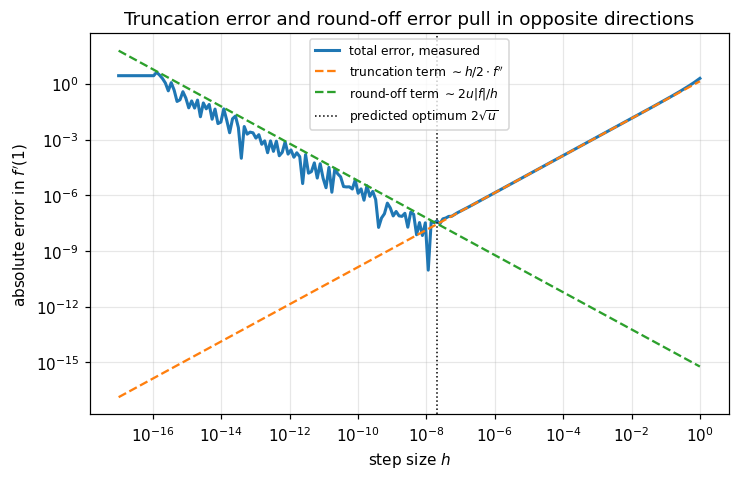

In [5]:
fig, ax = plt.subplots()
ax.loglog(h, total, "C0", lw=2, label="total error, measured")
ax.loglog(h, trunc, "C1--", lw=1.5, label=r"truncation term $\sim h/2 \cdot f''$")
ax.loglog(h, roundoff, "C2--", lw=1.5, label=r"round-off term $\sim 2u|f|/h$")
ax.axvline(h_star, color="k", ls=":", lw=1, label=r"predicted optimum $2\sqrt{u}$")
ax.set_xlabel("step size $h$")
ax.set_ylabel("absolute error in $f'(1)$")
ax.set_title("Truncation error and round-off error pull in opposite directions")
ax.legend(fontsize=8, loc="upper center")
plt.show()

**What to take from this.** The V shape is the signature of the trade-off, and you will meet
it again and again. On the right, truncation dominates and the error falls with slope $+1$.
On the left, round-off dominates and the error rises with slope $-1$, and the curve becomes
ragged because it is made of rounding noise rather than of anything smooth.

The bottom of the V is the best this formula can do, and it sits near $10^{-8}$ rather than
$10^{-16}$. **Roughly half your significant digits are gone**, and no amount of shrinking $h$
brings them back. Individual points on the ragged left branch sometimes dip lower by accident,
when the truncation and rounding errors happen to have opposite signs, but that is luck and
not a method.

## 4. Propagation through arithmetic

Now suppose the inputs already carry error, and ask what the output inherits. Write
$\hat{a} = a(1 + \epsilon_a)$ and $\hat{b} = b(1 + \epsilon_b)$ where $\epsilon$ denotes
relative error.

### Multiplication

$$\hat{a}\hat{b} = ab(1+\epsilon_a)(1+\epsilon_b) = ab\left(1 + \epsilon_a + \epsilon_b +
\epsilon_a \epsilon_b\right) \approx ab(1 + \epsilon_a + \epsilon_b).$$

> **Relative errors add under multiplication.** $|\epsilon_{ab}| \le |\epsilon_a| +
> |\epsilon_b|$.

### Division

$$\frac{\hat{a}}{\hat{b}} = \frac{a(1+\epsilon_a)}{b(1+\epsilon_b)}
\approx \frac{a}{b}(1 + \epsilon_a)(1 - \epsilon_b)
\approx \frac{a}{b}(1 + \epsilon_a - \epsilon_b).$$

> **Relative errors add under division too.** $|\epsilon_{a/b}| \le |\epsilon_a| +
> |\epsilon_b|$.

Multiplication and division are **safe**. Relative error grows only additively, one unit per
operation.

### Addition and subtraction

Here it is different, and this is the whole reason lesson 05 exists. Absolute errors add:

$$\hat{a} + \hat{b} = (a + b) + (a\epsilon_a + b\epsilon_b),$$

so the **relative** error of the sum is

$$\epsilon_{a+b} = \frac{a\epsilon_a + b\epsilon_b}{a+b},
\qquad\text{giving}\qquad
|\epsilon_{a+b}| \le \frac{|a||\epsilon_a| + |b||\epsilon_b|}{|a+b|}.$$

Look at that denominator. If $a + b$ is tiny while $a$ and $b$ are not, the bound blows up.
That is **catastrophic cancellation**, and it happens only in addition and subtraction.

> **Definition 4.3 (Cancellation factor).** For a subtraction $a - b$, the factor
> $$\frac{|a| + |b|}{|a - b|}$$
> is how much the relative error is multiplied. It equals 1 when there is no cancellation and
> grows without bound as $b \to a$.

In [6]:
print(f"{'a':>18} {'b':>10} {'a - b':>14} {'cancel factor':>15} {'digits lost':>12}")
print("-" * 74)
for a, b in [(1.0, 0.5), (1.0, 0.9), (1.0, 0.99), (1.0, 0.999999),
             (1.0, 1.0 - 1e-12), (1.0, 1.0 - 1e-15)]:
    cf = err.cancellation_factor(a, b)
    print(f"{a:>18.15f} {b:>10.6f} {a - b:>14.3e} {cf:>15.3e} "
          f"{np.log10(cf):>12.1f}")

print("\nmultiplication costs you one unit of relative error.")
print("subtracting nearly equal numbers can cost you every digit you have.")

                 a          b          a - b   cancel factor  digits lost
--------------------------------------------------------------------------
 1.000000000000000   0.500000      5.000e-01       3.000e+00          0.5
 1.000000000000000   0.900000      1.000e-01       1.900e+01          1.3
 1.000000000000000   0.990000      1.000e-02       1.990e+02          2.3
 1.000000000000000   0.999999      1.000e-06       2.000e+06          6.3
 1.000000000000000   1.000000      1.000e-12       2.000e+12         12.3
 1.000000000000000   1.000000      9.992e-16       2.002e+15         15.3

multiplication costs you one unit of relative error.
subtracting nearly equal numbers can cost you every digit you have.


Now confirm the rules numerically rather than trusting the algebra.

In [7]:
rng_local = np.random.default_rng(SEED)

a, b = 3.0, 7.0
eps_a, eps_b = 1e-6, 2e-6            # relative errors in the inputs

# Worst case is when both errors push the same way.
a_hat = a * (1 + eps_a)
b_hat = b * (1 + eps_b)

measured_prod = abs((a_hat * b_hat) - (a * b)) / abs(a * b)
predicted_prod = err.rel_error_product(eps_a, eps_b)

measured_quot = abs((a_hat / b_hat) - (a / b)) / abs(a / b)
predicted_quot = err.rel_error_quotient(eps_a, eps_b)

measured_sum = abs((a_hat + b_hat) - (a + b)) / abs(a + b)
predicted_sum = err.rel_error_sum(a, b, eps_a, eps_b)

print(f"{'operation':>14} {'measured':>14} {'predicted bound':>18} {'holds?':>8}")
print("-" * 58)
for name, m, p in [("a * b", measured_prod, predicted_prod),
                   ("a / b", measured_quot, predicted_quot),
                   ("a + b", measured_sum, predicted_sum)]:
    print(f"{name:>14} {m:>14.6e} {p:>18.6e} {str(m <= p * 1.001):>8}")
    assert m <= p * 1.001, name

print("\nevery first order bound held.")

     operation       measured    predicted bound   holds?
----------------------------------------------------------
         a * b   3.000002e-06       3.000000e-06     True
         a / b   9.999980e-07       3.000000e-06     True
         a + b   1.700000e-06       1.700000e-06     True

every first order bound held.


## 5. Propagation through a function of one variable

If $\hat{x} = x + \Delta x$ and you compute $f(\hat{x})$, a Taylor expansion gives

$$f(\hat{x}) = f(x) + f'(x)\,\Delta x + \tfrac{1}{2} f''(\xi)(\Delta x)^2,$$

so to first order

$$\boxed{|\Delta f| \approx |f'(x)| \, |\Delta x|.}$$

The derivative is the **amplification factor** for absolute error. In relative terms,

$$\frac{|\Delta f|}{|f(x)|} \approx \underbrace{\left|\frac{x f'(x)}{f(x)}\right|}_{\text{condition number}} \cdot \frac{|\Delta x|}{|x|}.$$

That bracketed quantity is the **relative condition number** of evaluating $f$ at $x$. It is
our first condition number, and lesson 06 generalises it. It says: a relative error of
$10^{-16}$ in the input becomes a relative error of $\kappa \times 10^{-16}$ in the output,
whatever algorithm you use.

In [8]:
tests = [
    ("exp(x) at x=1",      np.exp,             1.0),
    ("exp(x) at x=20",     np.exp,             20.0),
    ("sqrt(x) at x=4",     np.sqrt,            4.0),
    ("log(x) at x=1.001",  np.log,             1.001),
    ("tan(x) near pi/2",   np.tan,             np.pi/2 - 1e-4),
]

print(f"{'function':>22} {'condition number':>19} {'digits lost':>13}")
print("-" * 58)
for name, f, x in tests:
    k = err.condition_number_scalar(f, x)
    print(f"{name:>22} {k:>19.4e} {max(0.0, np.log10(k)):>13.1f}")

print("\nsqrt halves the relative error (kappa = 0.5): it is better conditioned than its input.")
print("exp at x = 20 multiplies it by 20.")
print("log near 1 is terrible, because log(1) = 0 and relative error is measured against it.")

              function    condition number   digits lost
----------------------------------------------------------
         exp(x) at x=1          1.0000e+00           0.0
        exp(x) at x=20          2.0000e+01           1.3
        sqrt(x) at x=4          5.0000e-01           0.0
     log(x) at x=1.001          1.0005e+03           3.0
      tan(x) near pi/2          1.5850e+04           4.2

sqrt halves the relative error (kappa = 0.5): it is better conditioned than its input.
exp at x = 20 multiplies it by 20.
log near 1 is terrible, because log(1) = 0 and relative error is measured against it.


Check the theory against reality for $\sqrt{\cdot}$, where $\kappa = 1/2$ exactly:

In [9]:
x = 4.0
for rel_in in [1e-6, 1e-9, 1e-12]:
    x_hat = x * (1 + rel_in)
    rel_out = abs(np.sqrt(x_hat) - np.sqrt(x)) / np.sqrt(x)
    print(f"input rel error {rel_in:.0e}  ->  output rel error {rel_out:.4e}  "
          f"ratio {rel_out / rel_in:.4f}")

print("\nthe ratio is 0.5 every time, matching kappa = |x f'(x) / f(x)| = 1/2 for sqrt.")

input rel error 1e-06  ->  output rel error 5.0000e-07  ratio 0.5000
input rel error 1e-09  ->  output rel error 5.0000e-10  ratio 0.5000
input rel error 1e-12  ->  output rel error 5.0004e-13  ratio 0.5000

the ratio is 0.5 every time, matching kappa = |x f'(x) / f(x)| = 1/2 for sqrt.


## 6. Propagation through a function of several variables

For $f(x_1, \dots, x_n)$ the same argument with a multivariate Taylor expansion gives

$$\boxed{|\Delta f| \;\lesssim\; \sum_{i=1}^{n} \left|\frac{\partial f}{\partial x_i}\right| |\Delta x_i|.}$$

Each input contributes its own error, scaled by how sensitive $f$ is to it. This is the
formula behind every uncertainty calculation in experimental science.

Worked example: the volume of a cylinder, $V = \pi r^2 h$, where $r$ and $h$ are measured.

$$\frac{\partial V}{\partial r} = 2\pi r h, \qquad \frac{\partial V}{\partial h} = \pi r^2,$$

so

$$\frac{\Delta V}{V} \le 2\frac{\Delta r}{r} + \frac{\Delta h}{h}.$$

The radius error counts **twice** as much as the height error, because $r$ appears squared.

In [10]:
def cylinder_volume(r, h):
    return np.pi * r**2 * h

r, h = 5.0, 12.0
dr, dh = 0.01, 0.02                 # absolute measurement uncertainties

predicted = err.propagate_absolute(cylinder_volume, [r, h], [dr, dh])
by_hand = abs(2*np.pi*r*h) * dr + abs(np.pi*r**2) * dh

print(f"volume                       : {cylinder_volume(r, h):.4f}")
print(f"propagated absolute error    : {predicted:.6f}")
print(f"same thing computed by hand  : {by_hand:.6f}")
assert abs(predicted - by_hand) < 1e-6

rel = err.propagate_relative(cylinder_volume, [r, h], [dr/r, dh/h])
print(f"\npropagated relative error    : {rel:.6e}")
print(f"rule of thumb 2*dr/r + dh/h  : {2*dr/r + dh/h:.6e}")
assert abs(rel - (2*dr/r + dh/h)) < 1e-6

# Now check the linear estimate against a direct worst-case perturbation.
worst = 0.0
for sr in (-1, 1):
    for sh in (-1, 1):
        v = cylinder_volume(r + sr*dr, h + sh*dh)
        worst = max(worst, abs(v - cylinder_volume(r, h)))
print(f"\nlargest actual change over the four corner perturbations: {worst:.6f}")
print(f"first order estimate                                    : {predicted:.6f}")
print(f"the estimate is accurate to {abs(worst-predicted)/worst*100:.2f} percent")

volume                       : 942.4778
propagated absolute error    : 5.340708
same thing computed by hand  : 5.340708

propagated relative error    : 5.666667e-03
rule of thumb 2*dr/r + dh/h  : 5.666667e-03

largest actual change over the four corner perturbations: 5.350767
first order estimate                                    : 5.340708
the estimate is accurate to 0.19 percent


The first order estimate is close because the perturbations are small. It is an
**approximation**, not a bound, and it degrades when the inputs move far enough that the
second derivative matters.

## 7. Accumulation over many operations

The standard model says one operation costs at most $u$ of relative error. What does $n$
operations cost?

For a sum of $n$ numbers computed left to right, a careful analysis gives a worst case bound
proportional to $nu$, and a typical case closer to $\sqrt{n}\,u$ because the individual
rounding errors have random signs and partially cancel.

> **Worst case** grows like $n$. **Typical case** grows like $\sqrt{n}$, a random walk.

Let us measure which one actually happens.

In [11]:
import math

from nalib import floatingpoint as fpm

rng_local = np.random.default_rng(SEED)
sizes = np.array([10, 30, 100, 300, 1000, 3000, 10_000, 30_000, 100_000, 300_000])
trials = 30

mean_err = []
for n in sizes:
    errs = []
    for _ in range(trials):
        vals = rng_local.uniform(0.5, 1.5, size=int(n))
        # math.fsum is exactly rounded, so it is a genuine reference.
        # np.longdouble is NOT: on Windows it is an alias for float64.
        exact = math.fsum(vals.tolist())
        naive = fpm.naive_sum(vals)
        errs.append(abs(naive - exact) / abs(exact))
    mean_err.append(np.mean(errs))
mean_err = np.array(mean_err)

from nalib import convergence as cv
p, C = cv.fit_power_law(sizes, mean_err)
print(f"measured growth exponent of the mean relative error : {p:.3f}")
print(f"  0.5 would mean random walk behaviour (sqrt(n))")
print(f"  1.0 would mean worst case behaviour (n)")
assert 0.3 < p < 0.8, f"expected random-walk-like growth, measured {p}"

measured growth exponent of the mean relative error : 0.532
  0.5 would mean random walk behaviour (sqrt(n))
  1.0 would mean worst case behaviour (n)


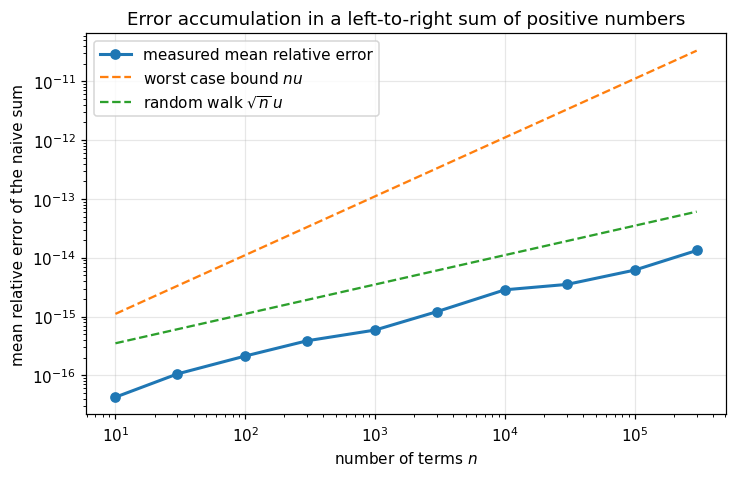

In [12]:
u = np.finfo(float).eps / 2
fig, ax = plt.subplots()
ax.loglog(sizes, mean_err, "o-", lw=2, label="measured mean relative error")
ax.loglog(sizes, u * sizes, "C1--", lw=1.5, label=r"worst case bound $n u$")
ax.loglog(sizes, u * np.sqrt(sizes), "C2--", lw=1.5, label=r"random walk $\sqrt{n}\, u$")
ax.set_xlabel("number of terms $n$")
ax.set_ylabel("mean relative error of the naive sum")
ax.set_title("Error accumulation in a left-to-right sum of positive numbers")
ax.legend()
plt.show()

**What to take from this.** The measured curve runs parallel to the $\sqrt{n}$ line, not the
$n$ line. The worst case bound is real but pessimistic for random data, because the rounding
errors have mixed signs and behave like a random walk. Data with structure, for instance
values that are all nearly equal and added in increasing order, can get much closer to the
worst case, and lesson 05 builds exactly such a case.

## 8. Complexity

Error propagation costs nothing at run time, since it is analysis rather than computation. But
the *estimates* have a cost when you compute them numerically:

| Task | Cost |
|---|---|
| Condition number of $f$ at a point, by central differences | 2 function evaluations |
| Propagated error for $n$ inputs | $2n$ function evaluations |
| Exact propagation with automatic differentiation | 1 forward pass plus 1 reverse pass, lesson 97 |

For $n$ large, the $2n$ evaluations are the reason people use automatic differentiation
instead of finite differences. Lesson 94 builds that from scratch.

## 9. Common mistakes

1. **Quoting absolute error with no scale.** "The error is 0.001" is not information.
2. **Assuming small relative error in the inputs gives small relative error in the output.**
   Only true if the condition number is modest. Section 5.
3. **Confusing truncation error with round-off error.** They respond to step size in opposite
   directions. Confusing them leads to the classic mistake of shrinking $h$ forever and
   watching the answer get worse.
4. **Using the worst case bound as a prediction.** $nu$ is a bound, not an estimate. For
   random data the truth is nearer $\sqrt{n}\,u$.
5. **Forgetting the linearisation is approximate.** The propagation formulas are first order.
   They fail for large perturbations or near a point where $f'$ vanishes.
6. **Treating inherent error as if numerical analysis could remove it.** If your input is
   measured to three digits, no algorithm gives you four.

## 10. Exercises

**Level 1, conceptual**

1.1 Classify each of the following: (a) modelling a bridge as a rigid beam, (b) storing $\pi$
as 3.14159, (c) using the first five terms of a Taylor series, (d) a typo in a coefficient,
(e) a thermometer reading to the nearest degree.

1.2 Why do relative errors add for multiplication but not for addition?

1.3 Your input data has 4 correct significant digits. Can a numerical method give you an
answer with 8 correct digits? Explain.

**Level 2, mathematical**

2.1 Derive the propagation rule for $f(x) = x^n$ and show the relative error is multiplied by
exactly $n$. Confirm with the condition number formula.

2.2 Show that the relative condition number of $f(x) = \sqrt{x}$ is $1/2$ for all $x > 0$, and
of $f(x) = \ln x$ is $1/|\ln x|$. Explain why the second blows up near $x = 1$.

2.3 For the sum $s = \sum_{i=1}^n x_i$ computed left to right under the standard model, prove
that the computed value satisfies $\hat{s} = \sum_i x_i (1 + \theta_i)$ with
$|\theta_i| \le (n-1)u + O(u^2)$. This is a **backward error** result: the computed sum is the
exact sum of slightly perturbed data.

**Level 3, computational**

3.1 Write your own `condition_number_scalar` and confirm it against the analytic values for
$\sqrt{x}$, $e^x$, $\ln x$ and $\tan x$.

3.2 Implement propagation for a function of $n$ variables and test it on the ideal gas law
$P = nRT/V$ with realistic uncertainties in $T$ and $V$.

3.3 Write a function that reports the number of correct significant digits of an
approximation, and test it on the partial sums of the series for $e$.

**Level 4, experimental**

4.1 Repeat the section 3 step-size experiment for the **central** difference
$(f(x+h) - f(x-h))/(2h)$. The truncation term is now $O(h^2)$. Predict the optimal $h$ and
the best achievable error, then measure them.

4.2 Repeat the section 7 accumulation experiment with values all equal to $0.1$, added in
order. Does the growth exponent move closer to 1? Explain why structure in the data matters.

4.3 Sort an array before summing it, ascending and then descending. Which order is more
accurate for positive values, and why?

**Level 5, advanced**

5.1 Derive a bound on the relative error of Horner's rule from lesson 01 under the standard
model. Show that the computed value is the exact value of a polynomial whose coefficients have
been perturbed by a relative amount at most $2nu + O(u^2)$. Conclude that Horner is backward
stable, and check the bound numerically.

5.2 The propagation formulas are first order. Derive the second order correction for a
function of one variable and find a case where the first order estimate is off by more than 10
percent.

5.3 Interval arithmetic carries a rigorous enclosure of the answer instead of a point estimate.
Implement a small interval arithmetic class supporting the four operations, and use it to
bound the value of the expanded $(x-1)^6$ from lesson 01 near $x = 1$. Compare the interval
width to the errors you measured there.

Solutions are in [`solutions/part01_foundations.md`](../solutions/part01_foundations.md).

## 11. Key takeaways

- **Relative error** is almost always the right measure, and
  $-\log_{10}(\text{relative error})$ gives the number of correct significant digits.
- Errors come from five places: **modeling**, **inherent** data error, **blunders**,
  **truncation** and **round-off**. Only the last two are ours to control.
- **Truncation and round-off pull in opposite directions.** The total error curve is a V, and
  its bottom is the best you can do.
- **Multiplication and division add relative errors**, one unit each. Safe.
- **Addition and subtraction add absolute errors**, so the relative error is scaled by
  $(|a|+|b|)/|a+b|$. That factor is unbounded, and it is the source of catastrophic
  cancellation.
- For a function, the **condition number** $|x f'(x)/f(x)|$ is the amplification factor for
  relative error, and for several variables the partial derivatives play the same role.
- Accumulated round-off grows like $n$ in the worst case and like $\sqrt{n}$ for random data.
  Measured here as an exponent close to $0.5$.

## Where this goes next

Section 4 identified subtraction of nearly equal numbers as the one operation that can destroy
everything. Lesson 05 is devoted to it: how to spot it, how to rewrite formulas to avoid it,
and how to sum a large array without losing accuracy. Lesson 06 then puts the condition number
of section 5 on a general footing and separates it cleanly from algorithm stability.

---

*Sources: Gupta, Numerical Methods, sections 2.1 (absolute, relative and percentage errors),
2.2 (modeling error, inherent error, blunder), 2.3.3.1 to 2.3.3.3 (propagated error in
arithmetic and in functions of one and several variables), 2.3.4 (truncation error) and 2.4
(accumulation of error); Sauer, Numerical Analysis 3rd ed., sections 0.3 and 5.1 for the
round-off against truncation trade-off. The measured random-walk growth exponent in section 7
is an experiment written for this course.*